# Experiment 1: NGRC Weight Analysis on the Lorenz System

## Objectives

- Generate Lorenz system data and train an NGRC model with \(k=1\).
- Extract and analyse the learned NGRC weights.
- Compare the learned coefficients with the Euler discretisation of the Lorenz equations.
- Investigate the effect of different time step sizes (\(dt\)).
- Identify the dominant linear and nonlinear interactions learned by NGRC.
- Examine how well NGRC recovers the underlying Lorenz dynamics.

In [1]:
# Source: LorenzConstLinQuadraticNVARtimedelay-RK23.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.integrate import solve_ivp

In [2]:
# Create output folders and file paths

OUTPUT_DIR = Path("../outputs")

IMAGE_DIR = OUTPUT_DIR / "images" / "lrz63_20"
LOG_DIR = OUTPUT_DIR / "logs"

LOG_FILE = LOG_DIR / "analysis_report.txt"

# Create directories if they do not exist

IMAGE_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

## Simulation Setup

### Generate Lorenz Data

The Lorenz system is used to generate the training and testing data for the NGRC model.

The system is defined as

$$
\frac{dx}{dt}=\sigma(y-x)
$$

$$
\frac{dy}{dt}=x(\rho-z)-y
$$

$$
\frac{dz}{dt}=xy-\beta z
$$

where $\sigma=10$, $\rho=28$, and $\beta=8/3$.

In [3]:
def generate_lorenz_data(dt, maxtime):

    # Lorenz63 parameters
    sigma = 10
    rho = 28
    beta = 8 / 3

    # Initial state
    initial_state = [
        17.67715816276679,
        12.931379185960404,
        43.91404334248268,
    ]

    # Time vector
    n_steps = round(maxtime / dt)
    t_eval = np.linspace(0, maxtime, n_steps + 1)

    # Lorenz63 equations
    def lorenz(t, state):

        x, y, z = state

        dx = sigma * (y - x)
        dy = x * (rho - z) - y
        dz = x * y - beta * z

        return [dx, dy, dz]

    # Numerical integration
    lorenz_soln = solve_ivp(
        lorenz,
        (0, maxtime),
        initial_state,
        t_eval=t_eval,
        method="RK23",
    )

    return lorenz_soln

### Build NGRC Feature Matrix

Construct the linear NGRC feature matrix from the Lorenz time series.

In [4]:
def build_ngrc_features(lorenz_soln, d, k):

    maxtime_pts = lorenz_soln.y.shape[1] - 1
    dlin = d * k

    x = np.zeros((dlin, maxtime_pts))

    for delay in range(k):
        for j in range(delay, maxtime_pts):

            x[
                d * delay:d * (delay + 1),
                j,
            ] = lorenz_soln.y[:, j - delay]

    return x

### Train the NGRC Model

Construct the training feature matrix, estimate the NGRC weights using ridge regression, and evaluate the training NRMSE.

In [5]:
def train_ngrc(
    x,
    d,
    k,
    warmup_pts,
    warmtrain_pts,
    traintime_pts,
    ridge_param,
    total_var,
):

    dlin = d * k
    dnonlin = dlin * (dlin + 1) // 2
    dtot = 1 + dlin + dnonlin

    # Training feature matrix
    out_train = np.ones((dtot, traintime_pts))

    out_train[1:dlin + 1, :] = (
        x[:, warmup_pts - 1:warmtrain_pts - 1]
    )

    cnt = 0

    for i in range(dlin):
        for j in range(i, dlin):

            out_train[dlin + 1 + cnt, :] = (
                x[i, warmup_pts - 1:warmtrain_pts - 1]
                * x[j, warmup_pts - 1:warmtrain_pts - 1]
            )

            cnt += 1

    # Training target
    Y = (
        x[0:d, warmup_pts:warmtrain_pts]
        - x[0:d, warmup_pts - 1:warmtrain_pts - 1]
    )

    # Ridge regression
    W_out = (
        Y
        @ out_train.T
        @ np.linalg.pinv(
            out_train @ out_train.T
            + ridge_param * np.eye(dtot)
        )
    )

    # Training prediction
    x_predict = (
        x[0:d, warmup_pts - 1:warmtrain_pts - 1]
        + W_out @ out_train
    )

    train_nrmse = np.sqrt(
        np.mean(
            (x[0:d, warmup_pts:warmtrain_pts] - x_predict) ** 2
        )
        / total_var
    )

    return W_out, train_nrmse

### Autonomous Prediction

Generate autonomous NGRC predictions on the test data and evaluate the prediction performance using the test NRMSE.

In [6]:
def predict_ngrc(
    x,
    W_out,
    d,
    k,
    warmtrain_pts,
    testtime_pts,
    lyaptime_pts,
    total_var,
):

    dlin = d * k
    dnonlin = dlin * (dlin + 1) // 2
    dtot = 1 + dlin + dnonlin

    out_test = np.zeros(dtot)

    x_test = np.zeros((dlin, testtime_pts))
    x_test[:, 0] = x[:, warmtrain_pts - 1]

    for j in range(testtime_pts - 1):

        out_test[1:dlin + 1] = x_test[:, j]

        cnt = 0

        for row in range(dlin):
            for col in range(row, dlin):

                out_test[dlin + 1 + cnt] = (
                    x_test[row, j]
                    * x_test[col, j]
                )

                cnt += 1

        x_test[d:dlin, j + 1] = (
            x_test[0:(dlin - d), j]
        )

        x_test[0:d, j + 1] = (
            x_test[0:d, j]
            + W_out @ out_test
        )

    true_segment = x[
        0:d,
        warmtrain_pts - 1:
        warmtrain_pts + lyaptime_pts - 1,
    ]

    pred_segment = x_test[
        0:d,
        0:lyaptime_pts,
    ]

    test_nrmse = np.sqrt(
        np.mean(
            (true_segment - pred_segment) ** 2
        )
        / total_var
    )

    return x_test, test_nrmse

In [7]:
def run_experiment(dt=0.025, ridge_param=2.5e-6, k=1):

    # Parameters
    warmup = 5.0
    traintime = 20.0
    testtime = 50.0
    lyaptime = 1.104

    maxtime = warmup + traintime + testtime

    # Time points
    warmup_pts = round(warmup / dt)
    traintime_pts = round(traintime / dt)
    warmtrain_pts = warmup_pts + traintime_pts

    testtime_pts = round(testtime / dt)
    lyaptime_pts = round(lyaptime / dt)

    # NVAR dimensions
    d = 3

    # Generate Lorenz data
    lorenz_soln = generate_lorenz_data(
        dt,
        maxtime,
    )

    total_var = np.var(lorenz_soln.y)

    # Build NGRC features
    x = build_ngrc_features(
        lorenz_soln,
        d,
        k,
    )

    # Train NGRC
    W_out, train_nrmse = train_ngrc(
        x,
        d,
        k,
        warmup_pts,
        warmtrain_pts,
        traintime_pts,
        ridge_param,
        total_var,
    )

    # Autonomous prediction
    x_test, test_nrmse = predict_ngrc(
        x,
        W_out,
        d,
        k,
        warmtrain_pts,
        testtime_pts,
        lyaptime_pts,
        total_var,
    )

    return {
        "dt": dt,
        "k": k,
        "ridge": ridge_param,
        "train_nrmse": train_nrmse,
        "test_nrmse": test_nrmse,
        "W_out": W_out,
        "x_test": x_test,

        "true_test": x[
            0:d,
            warmtrain_pts - 1:
            warmtrain_pts + testtime_pts - 1,
        ],
    }

In [8]:
def build_labels(d=3, k=1):

    variables = ["x", "y", "z"]

    linear_labels = []

    for delay in range(k):
        for var in variables:

            if delay == 0:
                linear_labels.append(
                    f"{var}(t)"
                )
            else:
                linear_labels.append(
                    f"{var}(t-{delay})"
                )

    labels = ["1"] + linear_labels

    for i in range(len(linear_labels)):
        for j in range(i, len(linear_labels)):

            labels.append(
                f"{linear_labels[i]}"
                f"*{linear_labels[j]}"
            )

    return labels

### Run the Experiments

Run the NGRC model for different values of the time step size ($dt$).

In [9]:
# Experiment settings

d = 3
k = 1
ridge_param = 2.5e-6

labels = build_labels(d=d, k=k)

dt_values = [
    1e-2,
    5e-3,
    2.5e-3,
    1e-3,
    5e-4,
    2.5e-4,
    1e-4,
    5e-5,
    2.5e-5,
    1e-5,
    5e-6,
    2.5e-6,
    1e-6,
]

results = []

for dt in dt_values:

    results.append(
        run_experiment(
            dt=dt,
            ridge_param=ridge_param,
            k=k,
        )
    )

    print(f"Completed dt={dt}")

print(f"Completed {len(results)} runs")

Completed dt=0.01
Completed dt=0.005
Completed dt=0.0025
Completed dt=0.001
Completed dt=0.0005
Completed dt=0.00025
Completed dt=0.0001
Completed dt=5e-05
Completed dt=2.5e-05
Completed dt=1e-05
Completed dt=5e-06
Completed dt=2.5e-06
Completed dt=1e-06
Completed 13 runs


### Extract Learned NGRC Weights

Store the learned coefficients and performance metrics for each experiment in a single dataframe.

In [10]:
equations = ["dx", "dy", "dz"]

rows = []

for result in results:

    W = result["W_out"]

    for eq, equation in enumerate(equations):

        row = {
            "dt": result["dt"],
            "equation": equation,
            "train_nrmse": result["train_nrmse"],
            "test_nrmse": result["test_nrmse"],
        }

        for i, label in enumerate(labels):

            row[label] = W[eq, i]

        rows.append(row)

weights_df = pd.DataFrame(rows)

weights_df.head()

,dt,equation,train_nrmse,test_nrmse,1,x(t),y(t),z(t),x(t)*x(t),x(t)*y(t),x(t)*z(t),y(t)*y(t),y(t)*z(t),z(t)*z(t)
0,0.010,dx,0.000977,0.159281,0.000085,-0.082034,0.095428,-0.000012,-0.000004,1.370638e-06,-0.000463,9.113127e-07,-0.000040,6.207018e-07
1,0.010,dy,0.000977,0.159281,-0.001594,0.265784,0.005883,0.000162,-0.000064,4.037528e-05,-0.009309,-7.313374e-07,-0.000895,2.637276e-06
2,0.010,dz,0.000977,0.159281,-0.063804,0.001040,-0.000723,-0.017635,0.000443,8.030820e-03,-0.000022,1.230598e-03,0.000019,-2.427294e-04
3,0.005,dx,0.000247,0.081541,0.000064,-0.045342,0.048816,-0.000008,-0.000001,2.887951e-07,-0.000122,4.530301e-07,-0.000009,2.940013e-07
4,0.005,dy,0.000247,0.081541,-0.000310,0.136627,-0.000957,0.000032,-0.000017,1.187211e-05,-0.004831,-9.059904e-07,-0.000231,8.887136e-07


### Euler Discretisation of the Lorenz System

The continuous Lorenz system is given by

$$
\frac{dx}{dt}=10(y-x)
$$

$$
\frac{dy}{dt}=x(28-z)-y
$$

$$
\frac{dz}{dt}=xy-\frac{8}{3}z
$$

Applying the forward Euler method gives

$$
\Delta x = -10\,dt\,x + 10\,dt\,y
$$

$$
\Delta y = 28\,dt\,x - dt\,y - dt\,xz
$$

$$
\Delta z = dt\,xy - \frac{8}{3}dt\,z
$$

The learned NGRC coefficients are compared with these Euler-discretised coefficients.

### Euler Prediction

Generate autonomous predictions using the Euler discretisation of the Lorenz system for comparison with NGRC and the RK23 reference solution.

In [11]:
def euler_predict(
    x0,
    dt,
    testtime_pts,
    sigma=10,
    beta=8 / 3,
    rho=28,
):

    d = len(x0)

    x_euler = np.zeros((d, testtime_pts))
    x_euler[:, 0] = x0

    for j in range(testtime_pts - 1):

        x_now, y_now, z_now = x_euler[:, j]

        dx = sigma * (y_now - x_now)
        dy = x_now * (rho - z_now) - y_now
        dz = x_now * y_now - beta * z_now

        x_euler[0, j + 1] = x_now + dt * dx
        x_euler[1, j + 1] = y_now + dt * dy
        x_euler[2, j + 1] = z_now + dt * dz

    return x_euler

## RK23, Euler, and NGRC Prediction Comparison

RK23 is used as the reference solution. Euler and NGRC predictions are compared for different values of $dt$.

### $dx/dt$ Equation

The Euler discretisation of the $x$ equation is

$$
x_{n+1}=x_n+dt\,\big[10(y_n-x_n)\big]
$$

In [12]:
euler_results = []

for result in results:

    dt = result["dt"]

    x0 = result["true_test"][:, 0]

    testtime_pts = result["true_test"].shape[1]

    x_euler = euler_predict(
        x0=x0,
        dt=dt,
        testtime_pts=testtime_pts,
    )

    euler_results.append(
        {
            "dt": dt,
            "x_euler": x_euler,
        }
    )

print(f"Completed {len(euler_results)} Euler runs")

Completed 13 Euler runs


In [13]:
weights_dx = weights_df[
    weights_df["equation"] == "dx"
].copy()

weights_dx = weights_dx.sort_values("dt")

# Euler discrete coefficients

weights_dx["Euler x(t)"] = (
    -10 * weights_dx["dt"]
)

weights_dx["Euler y(t)"] = (
    10 * weights_dx["dt"]
)

# Absolute errors

weights_dx["x_error"] = np.abs(
    weights_dx["x(t)"]
    - weights_dx["Euler x(t)"]
)

weights_dx["y_error"] = np.abs(
    weights_dx["y(t)"]
    - weights_dx["Euler y(t)"]
)

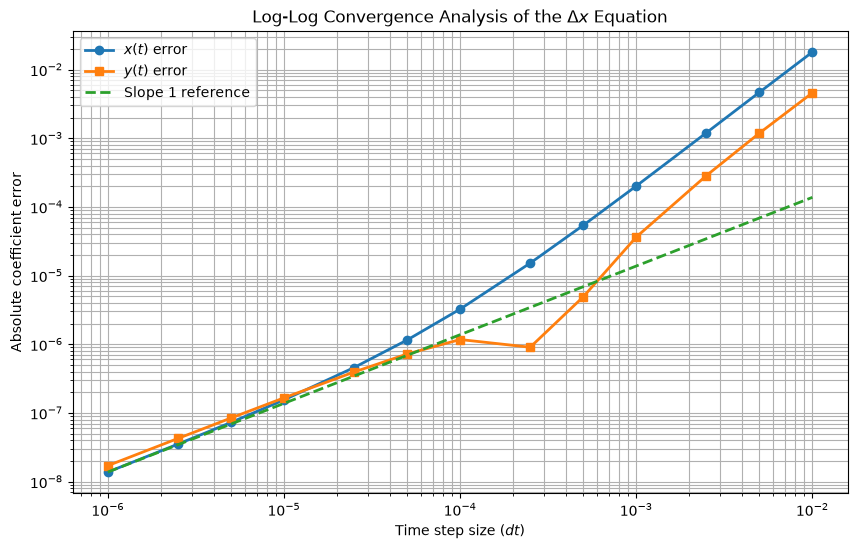

In [14]:


plt.figure(figsize=(10, 6))

plt.loglog(
    weights_dx["dt"],
    weights_dx["x_error"],
    marker="o",
    linewidth=2,
    label=r"$x(t)$ error",
)

plt.loglog(
    weights_dx["dt"],
    weights_dx["y_error"],
    marker="s",
    linewidth=2,
    label=r"$y(t)$ error",
)

# First-order reference line

dt_ref = np.array([
    weights_dx["dt"].min(),
    weights_dx["dt"].max(),
])

ref_line = (
    weights_dx["x_error"].iloc[0]
    * dt_ref
    / dt_ref[0]
)

plt.loglog(
    dt_ref,
    ref_line,
    "--",
    linewidth=2,
    label="Slope 1 reference",
)

plt.xlabel(r"Time step size ($dt$)")

plt.ylabel("Absolute coefficient error")

plt.title(
    r"Log-Log Convergence Analysis of the $\Delta x$ Equation"
)

plt.grid(
    True,
    which="both",
)

plt.legend()

plt.savefig(
    f"{IMAGE_DIR}/convergence_log_dx_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

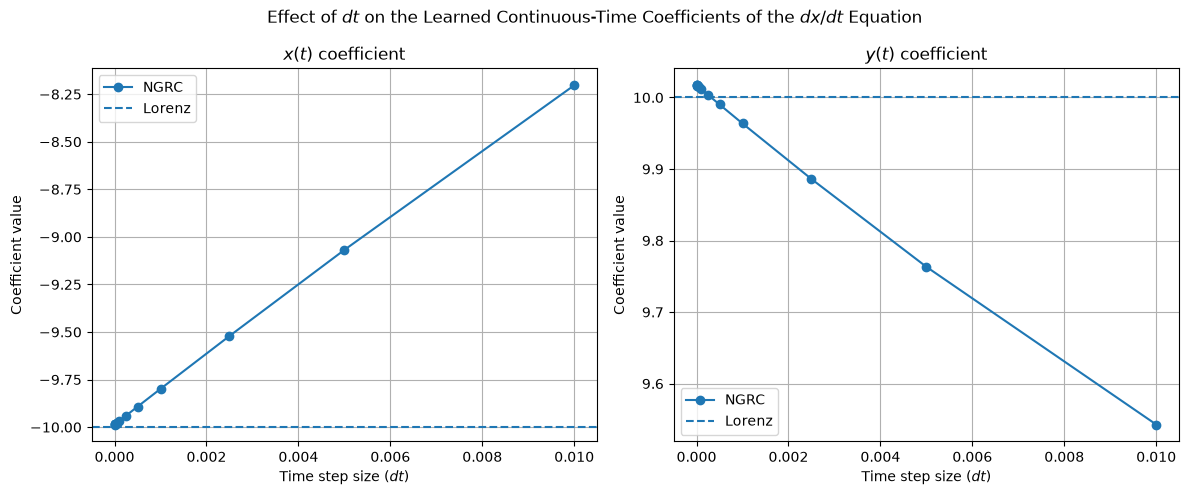

In [15]:
weights_dx = weights_dx.sort_values("dt")

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    sharex=True,
)

# x coefficient

axes[0].plot(
    weights_dx["dt"],
    weights_dx["x(t)"] / weights_dx["dt"],
    marker="o",
    label="NGRC",
)

axes[0].axhline(
    y=-10,
    linestyle="--",
    label="Lorenz",
)

axes[0].set_title(r"$x(t)$ coefficient")

axes[0].set_xlabel(r"Time step size ($dt$)")

axes[0].set_ylabel("Coefficient value")

axes[0].grid(True)

axes[0].legend()

# y coefficient

axes[1].plot(
    weights_dx["dt"],
    weights_dx["y(t)"] / weights_dx["dt"],
    marker="o",
    label="NGRC",
)

axes[1].axhline(
    y=10,
    linestyle="--",
    label="Lorenz",
)

axes[1].set_title(r"$y(t)$ coefficient")

axes[1].set_xlabel(r"Time step size ($dt$)")

axes[1].set_ylabel("Coefficient value")

axes[1].grid(True)

axes[1].legend()

plt.suptitle(
    r"Effect of $dt$ on the Learned Continuous-Time Coefficients of the $dx/dt$ Equation"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/dx_coefficients_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

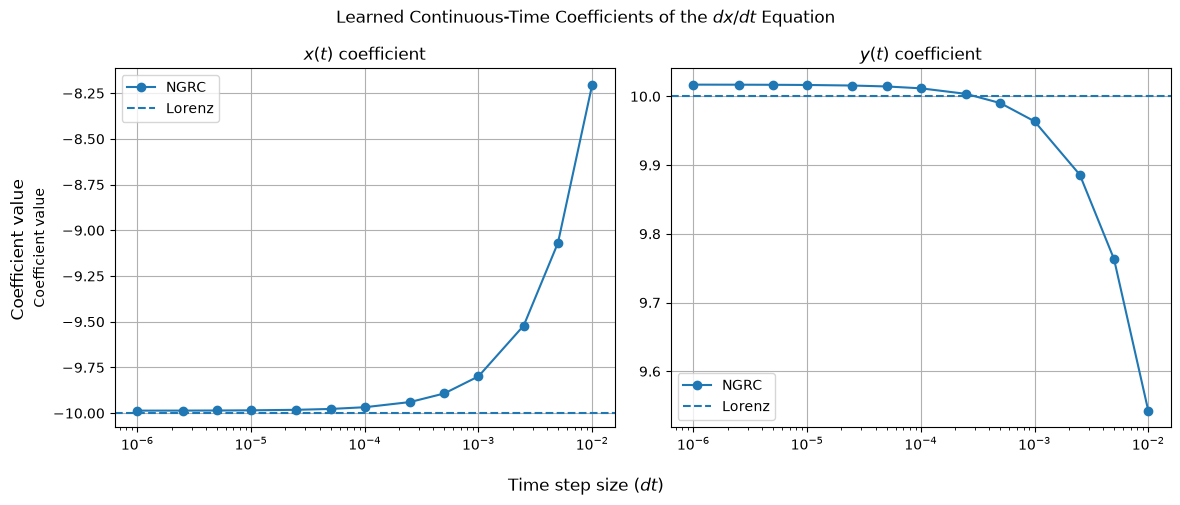

In [16]:
weights_dx = weights_dx.sort_values("dt")

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    sharex=True,
)

# x coefficient

axes[0].plot(
    weights_dx["dt"],
    weights_dx["x(t)"] / weights_dx["dt"],
    marker="o",
    label="NGRC",
)

axes[0].axhline(
    y=-10,
    linestyle="--",
    label="Lorenz",
)

axes[0].set_xscale("log")

axes[0].set_title(r"$x(t)$ coefficient")

axes[0].set_ylabel("Coefficient value")

axes[0].grid(True)

axes[0].legend()

# y coefficient

axes[1].plot(
    weights_dx["dt"],
    weights_dx["y(t)"] / weights_dx["dt"],
    marker="o",
    label="NGRC",
)

axes[1].axhline(
    y=10,
    linestyle="--",
    label="Lorenz",
)

axes[1].set_xscale("log")

axes[1].set_title(r"$y(t)$ coefficient")

axes[1].grid(True)

axes[1].legend()

fig.supxlabel(r"Time step size ($dt$)")

fig.supylabel("Coefficient value")

plt.suptitle(
    r"Learned Continuous-Time Coefficients of the $dx/dt$ Equation"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/dx_coefficients_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [ ]:
weights_dx = weights_df[
    weights_df["equation"] == "dx"
].copy()

weights_dx = weights_dx.sort_values("dt")

factor_cols = labels[1:]

rows = []

for _, row in weights_dx.iterrows():

    coeffs = row[factor_cols] / row["dt"]

    top3 = (
        coeffs.abs()
        .sort_values(ascending=False)
        .head(3)
    )

    rows.append({
        "dt": row["dt"],
        "1st": f"{top3.index[0]} ({coeffs[top3.index[0]]:.2f})",
        "2nd": f"{top3.index[1]} ({coeffs[top3.index[1]]:.2f})",
        "3rd": f"{top3.index[2]} ({coeffs[top3.index[2]]:.2f})",
    })

top3_dx = pd.DataFrame(rows)

top3_dx

,dt,1st,2nd,3rd
0,0.000001,y(t) (10.02),x(t) (-9.99),z(t) (-0.00)
1,0.000003,y(t) (10.02),x(t) (-9.99),z(t) (-0.00)
2,0.000005,y(t) (10.02),x(t) (-9.99),z(t) (-0.00)
3,0.000010,y(t) (10.02),x(t) (-9.98),z(t) (-0.00)
4,0.000025,y(t) (10.02),x(t) (-9.98),z(t) (-0.00)
5,0.000050,y(t) (10.01),x(t) (-9.98),z(t) (-0.00)
6,0.000100,y(t) (10.01),x(t) (-9.97),z(t) (-0.00)
7,0.000250,y(t) (10.00),x(t) (-9.94),z(t) (-0.00)
8,0.000500,y(t) (9.99),x(t) (-9.89),x(t)*z(t) (-0.00)
9,0.001000,y(t) (9.96),x(t) (-9.80),x(t)*z(t) (-0.01)


### $dy/dt$ Equation

The Euler discretisation of the $y$ equation is

$$
y_{n+1}=y_n+dt\,\big[x_n(28-z_n)-y_n\big]
$$

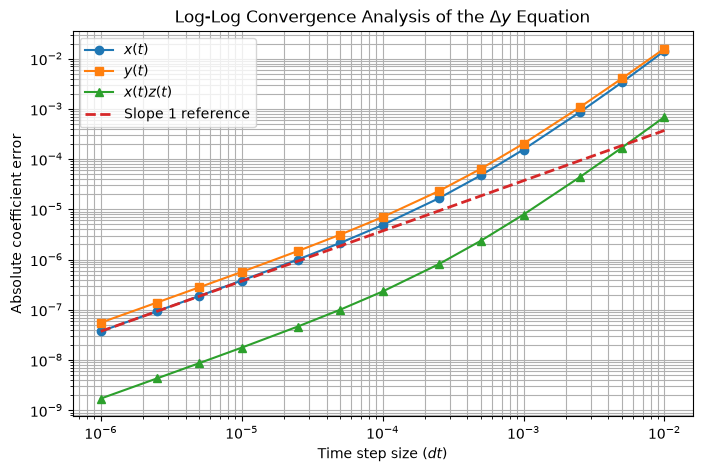

In [18]:
weights_dy = weights_df[
    weights_df["equation"] == "dy"
].copy()

weights_dy = weights_dy.sort_values("dt")

# Euler discrete coefficients

weights_dy["Euler x(t)"] = (
    28 * weights_dy["dt"]
)

weights_dy["Euler y(t)"] = (
    -1 * weights_dy["dt"]
)

weights_dy["Euler x(t)*z(t)"] = (
    -1 * weights_dy["dt"]
)

# Absolute errors

weights_dy["x_error"] = np.abs(
    weights_dy["x(t)"]
    - weights_dy["Euler x(t)"]
)

weights_dy["y_error"] = np.abs(
    weights_dy["y(t)"]
    - weights_dy["Euler y(t)"]
)

weights_dy["xz_error"] = np.abs(
    weights_dy["x(t)*z(t)"]
    - weights_dy["Euler x(t)*z(t)"]
)

plt.figure(figsize=(8, 5))

plt.loglog(
    weights_dy["dt"],
    weights_dy["x_error"],
    marker="o",
    label=r"$x(t)$",
)

plt.loglog(
    weights_dy["dt"],
    weights_dy["y_error"],
    marker="s",
    label=r"$y(t)$",
)

plt.loglog(
    weights_dy["dt"],
    weights_dy["xz_error"],
    marker="^",
    label=r"$x(t)z(t)$",
)

# First-order reference line

dt_ref = np.array([
    weights_dy["dt"].min(),
    weights_dy["dt"].max(),
])

ref_line = (
    weights_dy["x_error"].iloc[0]
    * dt_ref
    / dt_ref[0]
)

plt.loglog(
    dt_ref,
    ref_line,
    "--",
    linewidth=2,
    label="Slope 1 reference",
)

plt.xlabel(r"Time step size ($dt$)")

plt.ylabel("Absolute coefficient error")

plt.title(
    r"Log-Log Convergence Analysis of the $\Delta y$ Equation"
)

plt.grid(
    True,
    which="both",
)

plt.legend()

plt.savefig(
    f"{IMAGE_DIR}/convergence_log_dy_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

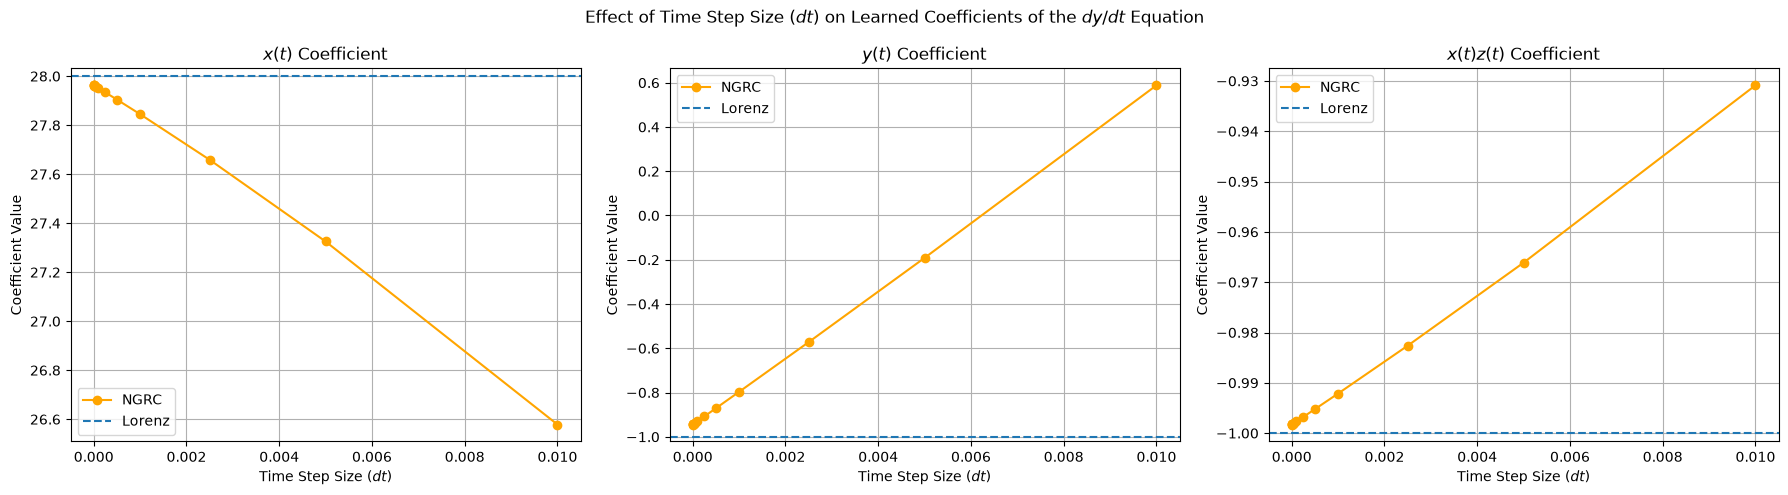

In [19]:
weights_dy = weights_df[
    weights_df["equation"] == "dy"
].copy()

# Convert NGRC coefficients to continuous-time form

weights_dy["NGRC x(t)/dt"] = weights_dy["x(t)"] / weights_dy["dt"]
weights_dy["NGRC y(t)/dt"] = weights_dy["y(t)"] / weights_dy["dt"]
weights_dy["NGRC x(t)*z(t)/dt"] = weights_dy["x(t)*z(t)"] / weights_dy["dt"]

# Analytical Lorenz coefficients

weights_dy["Lorenz x(t)"] = 28
weights_dy["Lorenz y(t)"] = -1
weights_dy["Lorenz x(t)*z(t)"] = -1

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True)

# x coefficient

axes[0].plot(
    weights_dy["dt"],
    weights_dy["NGRC x(t)/dt"],
    marker="o",
    color="orange",
    label="NGRC",
)

axes[0].axhline(y=28, linestyle="--", label="Lorenz")
axes[0].set_title(r"$x(t)$ Coefficient")
axes[0].set_xlabel(r"Time Step Size ($dt$)")
axes[0].set_ylabel("Coefficient Value")
axes[0].grid(True)
axes[0].legend()

# y coefficient

axes[1].plot(
    weights_dy["dt"],
    weights_dy["NGRC y(t)/dt"],
    marker="o",
    color="orange",
    label="NGRC",
)

axes[1].axhline(y=-1, linestyle="--", label="Lorenz")
axes[1].set_title(r"$y(t)$ Coefficient")
axes[1].set_xlabel(r"Time Step Size ($dt$)")
axes[1].set_ylabel("Coefficient Value")
axes[1].grid(True)
axes[1].legend()

# xz coefficient

axes[2].plot(
    weights_dy["dt"],
    weights_dy["NGRC x(t)*z(t)/dt"],
    marker="o",
    color="orange",
    label="NGRC",
)

axes[2].axhline(y=-1, linestyle="--", label="Lorenz")
axes[2].set_title(r"$x(t)z(t)$ Coefficient")
axes[2].set_xlabel(r"Time Step Size ($dt$)")
axes[2].set_ylabel("Coefficient Value")
axes[2].grid(True)
axes[2].legend()

plt.suptitle(
    r"Effect of Time Step Size ($dt$) on Learned Coefficients of the $dy/dt$ Equation"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/dy_coefficients_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

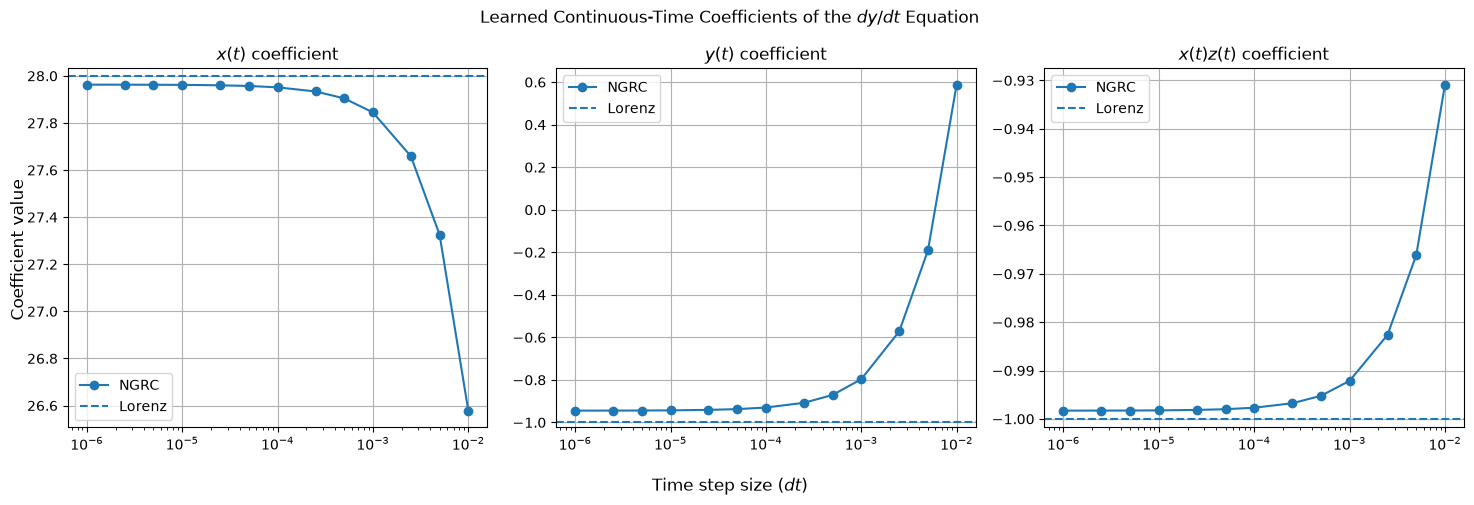

In [20]:
weights_dy = weights_dy.sort_values("dt")

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5),
    sharex=True,
)

# x coefficient

axes[0].plot(
    weights_dy["dt"],
    weights_dy["x(t)"] / weights_dy["dt"],
    marker="o",
    label="NGRC",
)

axes[0].axhline(
    y=28,
    linestyle="--",
    label="Lorenz",
)

axes[0].set_xscale("log")

axes[0].set_title(r"$x(t)$ coefficient")

axes[0].grid(True)

axes[0].legend()

# y coefficient

axes[1].plot(
    weights_dy["dt"],
    weights_dy["y(t)"] / weights_dy["dt"],
    marker="o",
    label="NGRC",
)

axes[1].axhline(
    y=-1,
    linestyle="--",
    label="Lorenz",
)

axes[1].set_xscale("log")

axes[1].set_title(r"$y(t)$ coefficient")

axes[1].grid(True)

axes[1].legend()

# xz coefficient

axes[2].plot(
    weights_dy["dt"],
    weights_dy["x(t)*z(t)"] / weights_dy["dt"],
    marker="o",
    label="NGRC",
)

axes[2].axhline(
    y=-1,
    linestyle="--",
    label="Lorenz",
)

axes[2].set_xscale("log")

axes[2].set_title(r"$x(t)z(t)$ coefficient")

axes[2].grid(True)

axes[2].legend()

fig.supxlabel(r"Time step size ($dt$)")

fig.supylabel("Coefficient value")

plt.suptitle(
    r"Learned Continuous-Time Coefficients of the $dy/dt$ Equation"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/dy_coefficients_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [21]:
weights_dy = weights_df[
    weights_df["equation"] == "dy"
].copy()

weights_dy = weights_dy.sort_values("dt")

factor_cols = labels[1:]

rows = []

for _, row in weights_dy.iterrows():

    coeffs = row[factor_cols] / row["dt"]

    top3 = (
        coeffs.abs()
        .sort_values(ascending=False)
        .head(3)
    )

    rows.append({
        "dt": row["dt"],
        "1st": f"{top3.index[0]} ({coeffs[top3.index[0]]:.2f})",
        "2nd": f"{top3.index[1]} ({coeffs[top3.index[1]]:.2f})",
        "3rd": f"{top3.index[2]} ({coeffs[top3.index[2]]:.2f})",
    })

top3_dy = pd.DataFrame(rows)

top3_dy

,dt,1st,2nd,3rd
0,0.000001,x(t) (27.96),x(t)*z(t) (-1.00),y(t) (-0.94)
1,0.000003,x(t) (27.96),x(t)*z(t) (-1.00),y(t) (-0.94)
2,0.000005,x(t) (27.96),x(t)*z(t) (-1.00),y(t) (-0.94)
3,0.000010,x(t) (27.96),x(t)*z(t) (-1.00),y(t) (-0.94)
4,0.000025,x(t) (27.96),x(t)*z(t) (-1.00),y(t) (-0.94)
5,0.000050,x(t) (27.96),x(t)*z(t) (-1.00),y(t) (-0.94)
6,0.000100,x(t) (27.95),x(t)*z(t) (-1.00),y(t) (-0.93)
7,0.000250,x(t) (27.93),x(t)*z(t) (-1.00),y(t) (-0.91)
8,0.000500,x(t) (27.90),x(t)*z(t) (-1.00),y(t) (-0.87)
9,0.001000,x(t) (27.84),x(t)*z(t) (-0.99),y(t) (-0.80)


### $dz/dt$ Equation

The Euler discretisation of the $z$ equation is

$$
z_{n+1}=z_n+dt\,\big[x_ny_n-\frac{8}{3}z_n\big]
$$

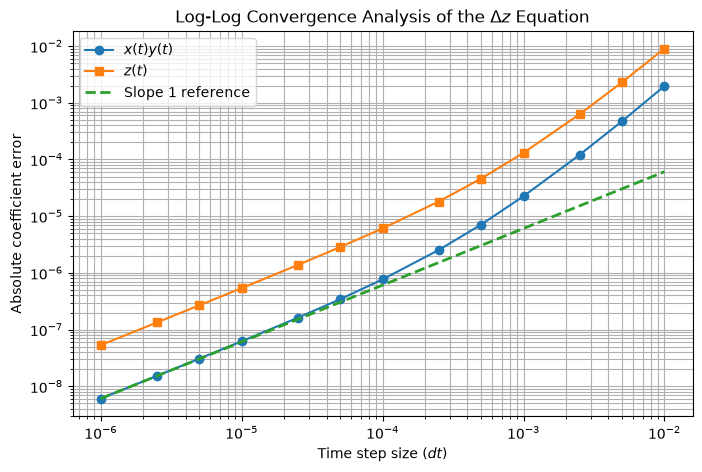

In [22]:
weights_dz = weights_df[
    weights_df["equation"] == "dz"
].copy()

weights_dz = weights_dz.sort_values("dt")

# Euler discrete coefficients

weights_dz["Euler x(t)*y(t)"] = (
    1 * weights_dz["dt"]
)

weights_dz["Euler z(t)"] = (
    -(8 / 3) * weights_dz["dt"]
)

# Absolute errors

weights_dz["xy_error"] = np.abs(
    weights_dz["x(t)*y(t)"]
    - weights_dz["Euler x(t)*y(t)"]
)

weights_dz["z_error"] = np.abs(
    weights_dz["z(t)"]
    - weights_dz["Euler z(t)"]
)

plt.figure(figsize=(8, 5))

plt.loglog(
    weights_dz["dt"],
    weights_dz["xy_error"],
    marker="o",
    label=r"$x(t)y(t)$",
)

plt.loglog(
    weights_dz["dt"],
    weights_dz["z_error"],
    marker="s",
    label=r"$z(t)$",
)

# First-order reference line

dt_ref = np.array([
    weights_dz["dt"].min(),
    weights_dz["dt"].max(),
])

ref_line = (
    weights_dz["xy_error"].iloc[0]
    * dt_ref
    / dt_ref[0]
)

plt.loglog(
    dt_ref,
    ref_line,
    "--",
    linewidth=2,
    label="Slope 1 reference",
)

plt.xlabel(r"Time step size ($dt$)")

plt.ylabel("Absolute coefficient error")

plt.title(
    r"Log-Log Convergence Analysis of the $\Delta z$ Equation"
)

plt.grid(
    True,
    which="both",
)

plt.legend()

plt.savefig(
    f"{IMAGE_DIR}/convergence_log_dz_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

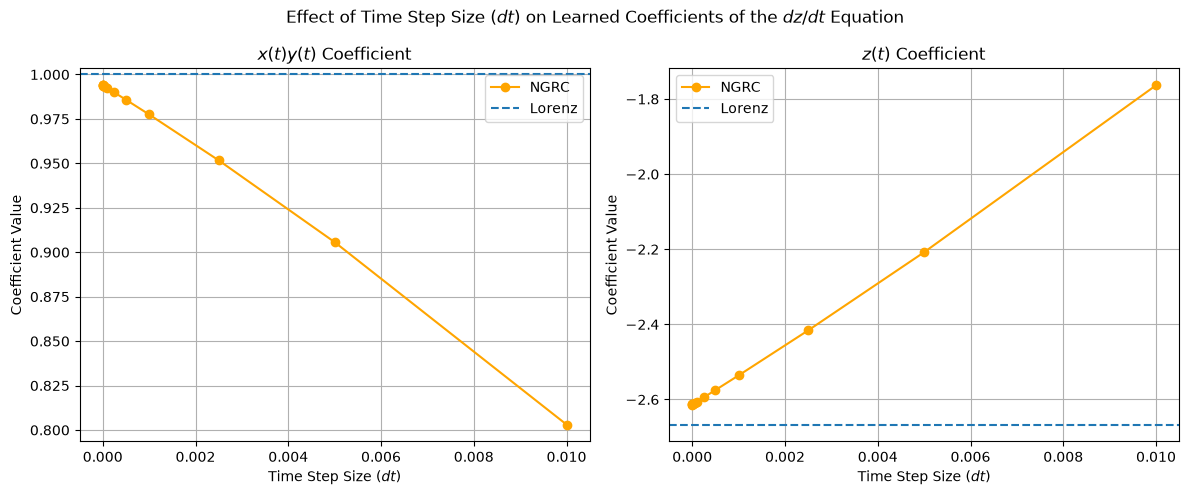

In [23]:
weights_dz = weights_df[
    weights_df["equation"] == "dz"
].copy()

# Convert NGRC coefficients to continuous-time form

weights_dz["NGRC x(t)*y(t)/dt"] = weights_dz["x(t)*y(t)"] / weights_dz["dt"]

weights_dz["NGRC z(t)/dt"] = weights_dz["z(t)"] / weights_dz["dt"]

# Analytical Lorenz coefficients

weights_dz["Lorenz x(t)*y(t)"] = 1

weights_dz["Lorenz z(t)"] = -(8 / 3)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)

# xy coefficient

axes[0].plot(
    weights_dz["dt"],
    weights_dz["NGRC x(t)*y(t)/dt"],
    marker="o",
    color="orange",
    label="NGRC",
)

axes[0].axhline(y=1, linestyle="--", label="Lorenz")

axes[0].set_title(r"$x(t)y(t)$ Coefficient")

axes[0].set_xlabel(r"Time Step Size ($dt$)")

axes[0].set_ylabel("Coefficient Value")

axes[0].grid(True)

axes[0].legend()

# z coefficient

axes[1].plot(
    weights_dz["dt"],
    weights_dz["NGRC z(t)/dt"],
    marker="o",
    color="orange",
    label="NGRC",
)

axes[1].axhline(y=-(8 / 3), linestyle="--", label="Lorenz")

axes[1].set_title(r"$z(t)$ Coefficient")

axes[1].set_xlabel(r"Time Step Size ($dt$)")

axes[1].set_ylabel("Coefficient Value")

axes[1].grid(True)

axes[1].legend()

plt.suptitle(
    r"Effect of Time Step Size ($dt$) on Learned Coefficients of the $dz/dt$ Equation"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/dz_coefficients_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

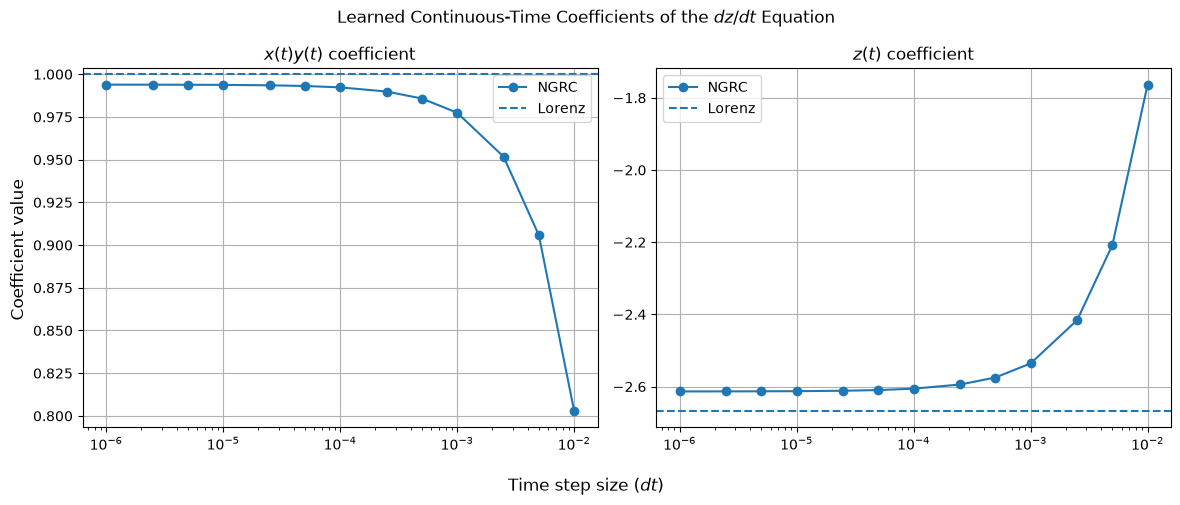

In [24]:
weights_dz = weights_dz.sort_values("dt")

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5),
    sharex=True,
)

# xy coefficient

axes[0].plot(
    weights_dz["dt"],
    weights_dz["x(t)*y(t)"] / weights_dz["dt"],
    marker="o",
    label="NGRC",
)

axes[0].axhline(
    y=1,
    linestyle="--",
    label="Lorenz",
)

axes[0].set_xscale("log")

axes[0].set_title(r"$x(t)y(t)$ coefficient")

axes[0].grid(True)

axes[0].legend()

# z coefficient

axes[1].plot(
    weights_dz["dt"],
    weights_dz["z(t)"] / weights_dz["dt"],
    marker="o",
    label="NGRC",
)

axes[1].axhline(
    y=-(8 / 3),
    linestyle="--",
    label="Lorenz",
)

axes[1].set_xscale("log")

axes[1].set_title(r"$z(t)$ coefficient")

axes[1].grid(True)

axes[1].legend()

fig.supxlabel(r"Time step size ($dt$)")

fig.supylabel("Coefficient value")

plt.suptitle(
    r"Learned Continuous-Time Coefficients of the $dz/dt$ Equation"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/dz_coefficients_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

In [25]:
weights_dz = weights_df[
    weights_df["equation"] == "dz"
].copy()

weights_dz = weights_dz.sort_values("dt")

factor_cols = labels[1:]

rows = []

for _, row in weights_dz.iterrows():

    coeffs = row[factor_cols] / row["dt"]

    top3 = (
        coeffs.abs()
        .sort_values(ascending=False)
        .head(3)
    )

    rows.append({
        "dt": row["dt"],
        "1st": f"{top3.index[0]} ({coeffs[top3.index[0]]:.2f})",
        "2nd": f"{top3.index[1]} ({coeffs[top3.index[1]]:.2f})",
        "3rd": f"{top3.index[2]} ({coeffs[top3.index[2]]:.2f})",
    })

top3_dz = pd.DataFrame(rows)

top3_dz

,dt,1st,2nd,3rd
0,0.000001,z(t) (-2.61),x(t)*y(t) (0.99),x(t) (0.01)
1,0.000003,z(t) (-2.61),x(t)*y(t) (0.99),x(t) (0.01)
2,0.000005,z(t) (-2.61),x(t)*y(t) (0.99),x(t) (0.01)
3,0.000010,z(t) (-2.61),x(t)*y(t) (0.99),x(t) (0.01)
4,0.000025,z(t) (-2.61),x(t)*y(t) (0.99),x(t) (0.01)
5,0.000050,z(t) (-2.61),x(t)*y(t) (0.99),x(t) (0.01)
6,0.000100,z(t) (-2.61),x(t)*y(t) (0.99),x(t) (0.01)
7,0.000250,z(t) (-2.59),x(t)*y(t) (0.99),x(t) (0.01)
8,0.000500,z(t) (-2.57),x(t)*y(t) (0.99),x(t) (0.01)
9,0.001000,z(t) (-2.54),x(t)*y(t) (0.98),x(t) (0.02)


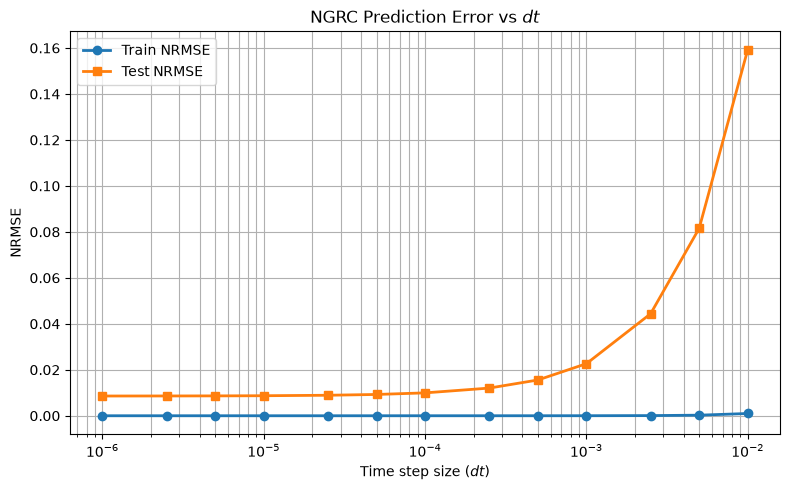

In [26]:
summary = pd.DataFrame([
    {
        "dt": r["dt"],
        "train_nrmse": r["train_nrmse"],
        "test_nrmse": r["test_nrmse"],
    }
    for r in results
])

summary = summary.sort_values("dt")

plt.figure(figsize=(8, 5))

plt.plot(
    summary["dt"],
    summary["train_nrmse"],
    marker="o",
    linewidth=2,
    label="Train NRMSE",
)

plt.plot(
    summary["dt"],
    summary["test_nrmse"],
    marker="s",
    linewidth=2,
    label="Test NRMSE",
)

plt.xscale("log")

# Uncomment if NRMSE spans multiple orders of magnitude
# plt.yscale("log")

plt.xlabel(r"Time step size ($dt$)")

plt.ylabel("NRMSE")

plt.title(
    r"NGRC Prediction Error vs $dt$"
)

plt.grid(
    True,
    which="both",
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/nrmse_vs_dt.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

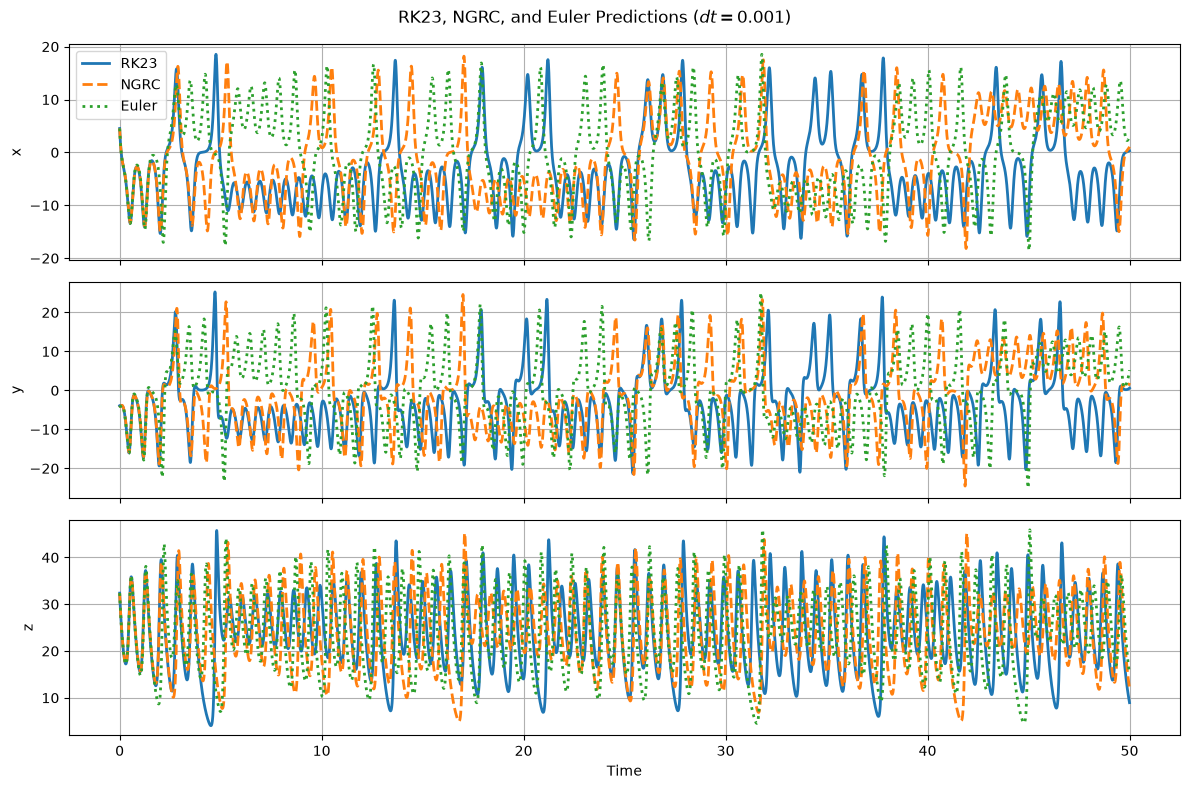

In [27]:
r = next(
    r for r in results
    if r["dt"] == 0.001
)

true = r["true_test"]

pred_ngrc = r["x_test"]

x_euler = euler_predict(
    x0=true[:, 0],
    dt=r["dt"],
    testtime_pts=pred_ngrc.shape[1],
)

n = pred_ngrc.shape[1]

time = np.arange(n) * r["dt"]

fig, axs = plt.subplots(
    3,
    1,
    figsize=(12, 8),
    sharex=True,
)

names = ["x", "y", "z"]

for i in range(3):

    axs[i].plot(
        time,
        true[i, :n],
        linewidth=2,
        label="RK23",
    )

    axs[i].plot(
        time,
        pred_ngrc[i, :n],
        "--",
        linewidth=2,
        label="NGRC",
    )

    axs[i].plot(
        time,
        x_euler[i, :n],
        ":",
        linewidth=2,
        label="Euler",
    )

    axs[i].set_ylabel(names[i])

    axs[i].grid(True)

axs[0].legend()

axs[-1].set_xlabel("Time")

plt.suptitle(
    f"RK23, NGRC, and Euler Predictions ($dt={r['dt']}$)"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/rk23_ngrc_euler.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

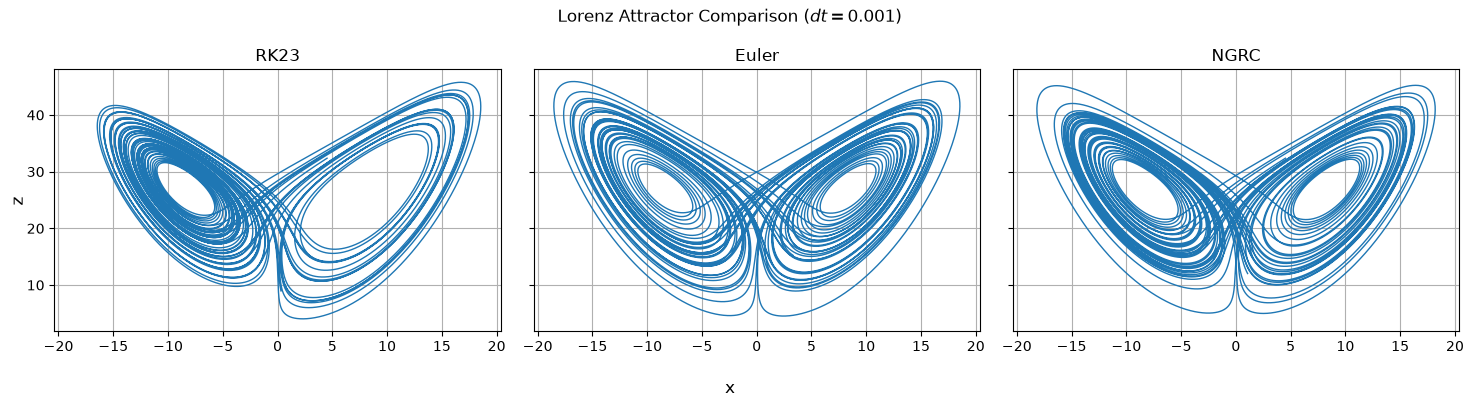

In [28]:
r = next(
    r for r in results
    if r["dt"] == 0.001
)

true = r["true_test"]

pred_ngrc = r["x_test"]

x_euler = euler_predict(
    x0=true[:, 0],
    dt=r["dt"],
    testtime_pts=pred_ngrc.shape[1],
)

n = pred_ngrc.shape[1]

fig, axs = plt.subplots(
    1,
    3,
    figsize=(15, 4),
    sharex=True,
    sharey=True,
)

# RK23

axs[0].plot(
    true[0, :n],
    true[2, :n],
    linewidth=1,
)

axs[0].set_title("RK23")

axs[0].grid(True)

# Euler

axs[1].plot(
    x_euler[0, :n],
    x_euler[2, :n],
    linewidth=1,
)

axs[1].set_title("Euler")

axs[1].grid(True)

# NGRC

axs[2].plot(
    pred_ngrc[0, :n],
    pred_ngrc[2, :n],
    linewidth=1,
)

axs[2].set_title("NGRC")

axs[2].grid(True)

fig.supxlabel("x")

fig.supylabel("z")

plt.suptitle(
    f"Lorenz Attractor Comparison ($dt={r['dt']}$)"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/lorenz_attractor_comparison.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

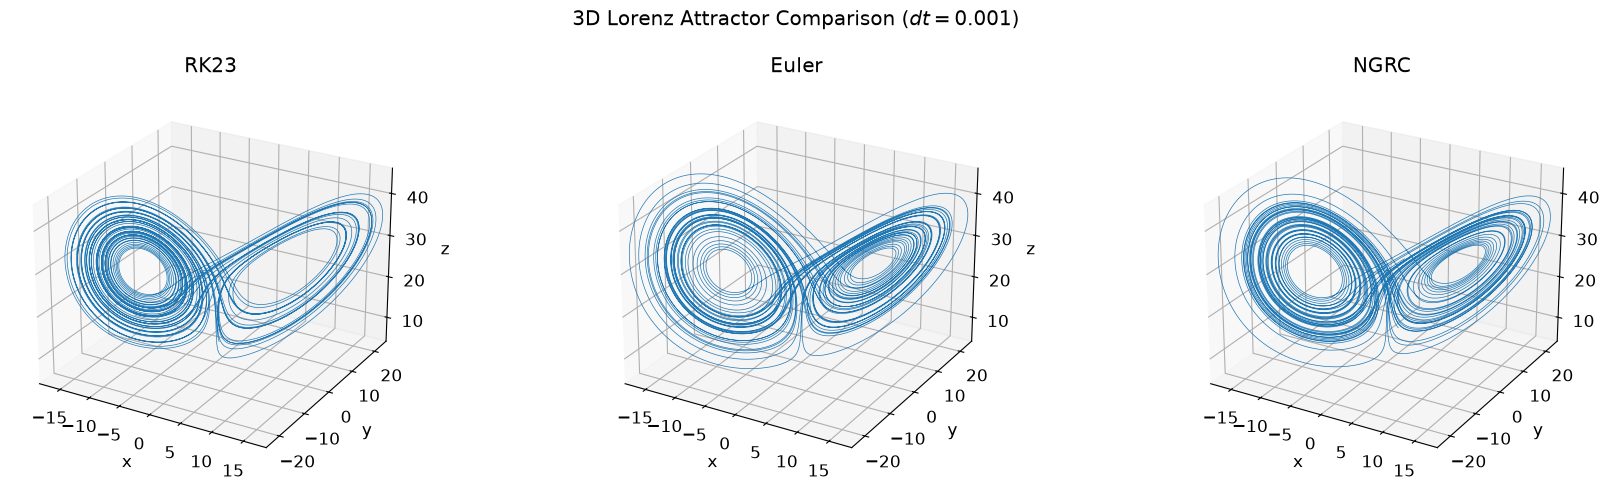

In [29]:
plt.rcParams.update({"font.size": 12})

r = next(
    r for r in results
    if r["dt"] == 0.001
)

true = r["true_test"]

pred_ngrc = r["x_test"]

x_euler = euler_predict(
    x0=true[:, 0],
    dt=r["dt"],
    testtime_pts=pred_ngrc.shape[1],
)

n = pred_ngrc.shape[1]

fig = plt.figure(figsize=(18, 5))

# Common axis limits

x_min = min(
    true[0, :n].min(),
    x_euler[0, :n].min(),
    pred_ngrc[0, :n].min(),
)

x_max = max(
    true[0, :n].max(),
    x_euler[0, :n].max(),
    pred_ngrc[0, :n].max(),
)

y_min = min(
    true[1, :n].min(),
    x_euler[1, :n].min(),
    pred_ngrc[1, :n].min(),
)

y_max = max(
    true[1, :n].max(),
    x_euler[1, :n].max(),
    pred_ngrc[1, :n].max(),
)

z_min = min(
    true[2, :n].min(),
    x_euler[2, :n].min(),
    pred_ngrc[2, :n].min(),
)

z_max = max(
    true[2, :n].max(),
    x_euler[2, :n].max(),
    pred_ngrc[2, :n].max(),
)

# RK23

ax1 = fig.add_subplot(
    131,
    projection="3d",
)

ax1.plot(
    true[0, :n],
    true[1, :n],
    true[2, :n],
    linewidth=0.5,
)

ax1.set_title("RK23")

# Euler

ax2 = fig.add_subplot(
    132,
    projection="3d",
)

ax2.plot(
    x_euler[0, :n],
    x_euler[1, :n],
    x_euler[2, :n],
    linewidth=0.5,
)

ax2.set_title("Euler")

# NGRC

ax3 = fig.add_subplot(
    133,
    projection="3d",
)

ax3.plot(
    pred_ngrc[0, :n],
    pred_ngrc[1, :n],
    pred_ngrc[2, :n],
    linewidth=0.5,
)

ax3.set_title("NGRC")

for ax in [ax1, ax2, ax3]:

    ax.set_xlim(x_min, x_max)

    ax.set_ylim(y_min, y_max)

    ax.set_zlim(z_min, z_max)

    ax.view_init(
        elev=25,
        azim=-60,
    )

    ax.set_xlabel("x")

    ax.set_ylabel("y")

    ax.set_zlabel("z")

plt.suptitle(
    f"3D Lorenz Attractor Comparison ($dt={r['dt']}$)"
)

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/lorenz_attractor_3d_comparison.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()

## Ridge Parameter Sensitivity Analysis

Investigate how changing the ridge regularisation parameter ($\lambda$) affects NGRC training and prediction performance while keeping $dt$ fixed.

In [30]:
d = 3

k = 1

dt = 0.01

labels = build_labels(
    d=d,
    k=k,
)

ridge_values = [
    0,
    1e-8,
    1e-7,
    1e-6,
    1e-5,
    1e-4,
    1e-3,
    1e-2,
    1e-1,
    1,
    10,
    100,
]

results_ridge = []

for ridge in ridge_values:

    results_ridge.append(
        run_experiment(
            dt=dt,
            ridge_param=ridge,
            k=k,
        )
    )

    print(f"Completed ridge={ridge}")

summary_ridge = pd.DataFrame([
    {
        "ridge": r["ridge"],
        "train_nrmse": r["train_nrmse"],
        "test_nrmse": r["test_nrmse"],
    }
    for r in results_ridge
])

summary_ridge = summary_ridge.sort_values(
    "ridge"
)

summary_ridge

Completed ridge=0
Completed ridge=1e-08
Completed ridge=1e-07
Completed ridge=1e-06
Completed ridge=1e-05
Completed ridge=0.0001
Completed ridge=0.001
Completed ridge=0.01
Completed ridge=0.1
Completed ridge=1
Completed ridge=10
Completed ridge=100


,ridge,train_nrmse,test_nrmse
0,0.000000e+00,0.000977,0.159281
1,1.000000e-08,0.000977,0.159281
2,1.000000e-07,0.000977,0.159281
3,1.000000e-06,0.000977,0.159281
4,1.000000e-05,0.000977,0.159281
5,1.000000e-04,0.000977,0.159281
6,1.000000e-03,0.000977,0.159278
7,1.000000e-02,0.000977,0.159247
8,1.000000e-01,0.000977,0.158948
9,1.000000e+00,0.000977,0.156125


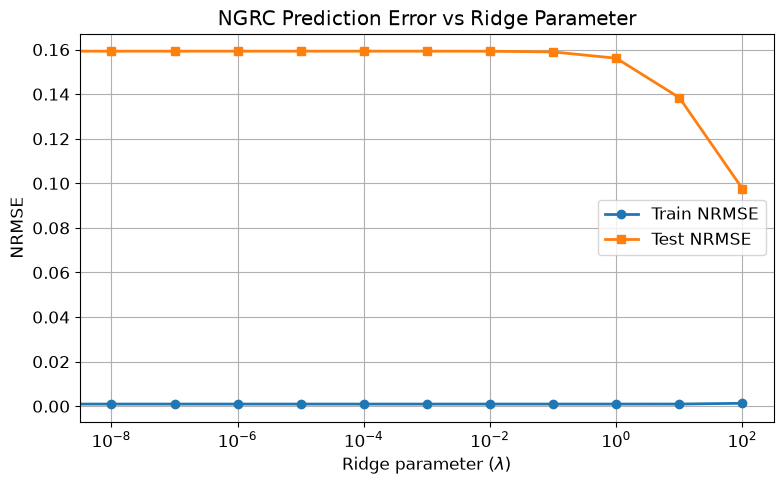

In [31]:
plt.figure(figsize=(8, 5))

plt.semilogx(
    summary_ridge["ridge"],
    summary_ridge["train_nrmse"],
    marker="o",
    linewidth=2,
    label="Train NRMSE",
)

plt.semilogx(
    summary_ridge["ridge"],
    summary_ridge["test_nrmse"],
    marker="s",
    linewidth=2,
    label="Test NRMSE",
)

plt.xlabel(r"Ridge parameter ($\lambda$)")

plt.ylabel("NRMSE")

plt.title(
    r"NGRC Prediction Error vs Ridge Parameter"
)

plt.grid(
    True,
    which="both",
)

plt.legend()

plt.tight_layout()

plt.savefig(
    f"{IMAGE_DIR}/nrmse_vs_ridge.png",
    dpi=150,
    bbox_inches="tight",
)

plt.show()